## AN IMAGE IS WORTH 16X16 WORDS: TRANSFORMERS FOR IMAGE RECOGNITION AT SCALE
https://arxiv.org/abs/2010.11929

## pytorch-image-models
https://github.com/huggingface/pytorch-image-models?tab=readme-ov-file#train-validation-inference-scripts

In [ ]:
!pip install torch torchvision timm scikit-learn matplotlib


In [ ]:
!apt-get install unrar -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [ ]:
!unrar x /content/imagefolder.rar /content/imagefolder/


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/imagefolder.rar


Would you like to replace the existing file /content/imagefolder/imagefolder/test/BIODEGRADABLE/paper1097_jpg.rf.ee519d607c7dfe2e745266c5e2e3234e.jpg
 22560 bytes, modified on 2025-07-16 18:38
with a new one
 22560 bytes, modified on 2025-07-16 18:38

[Y]es, [N]o, [A]ll, n[E]ver, [R]ename, [Q]uit 
User break

User break


In [ ]:
from collections import defaultdict
import os

def count_images_per_class(root_dir):
    class_counts = defaultdict(int)
    for class_name in os.listdir(root_dir):
        class_dir = os.path.join(root_dir, class_name)
        if os.path.isdir(class_dir):
            count = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            class_counts[class_name] = count
    return class_counts

# 分別統計 train / valid / test 資料夾
for split in ["train", "valid", "test"]:
    print(f"\n=== {split.upper()} set ===")
    path = os.path.join(imagefolder_root, split)
    counts = count_images_per_class(path)
    for class_name, count in sorted(counts.items()):
        print(f"{class_name:<15}: {count} 張")



=== TRAIN set ===
BIODEGRADABLE  : 1551 張
CARDBOARD      : 1016 張
GLASS          : 1852 張
METAL          : 874 張
PAPER          : 1215 張
PLASTIC        : 816 張

=== VALID set ===
BIODEGRADABLE  : 666 張
CARDBOARD      : 430 張
GLASS          : 795 張
METAL          : 205 張
PAPER          : 2 張

=== TEST set ===
BIODEGRADABLE  : 3 張
CARDBOARD      : 9 張
METAL          : 170 張
PAPER          : 512 張
PLASTIC        : 348 張


In [ ]:
for images, labels in train_loader:
    print(f"Max label: {labels.max().item()}, Min label: {labels.min().item()}")
    break


Max label: 5, Min label: 0


In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import timm
from tqdm import tqdm
from torch.optim.lr_scheduler import StepLR
import numpy as np

# ========================
# Config
# ========================
imagefolder_root = "/content/imagefolder/imagefolder"
model_name = "vit_tiny_patch16_224"
batch_size = 32
num_epochs = 10
lr = 1e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

[Train] Epoch 1/10: 100%|██████████| 229/229 [00:48<00:00,  4.75it/s]

Epoch 1 | Train Loss: 0.4316


Epoch 1 | Val Loss: 0.1745, Val Acc: 0.9442


[Train] Epoch 2/10: 100%|██████████| 229/229 [00:48<00:00,  4.76it/s]

Epoch 2 | Train Loss: 0.2139


...

Epoch 9 | Train Loss: 0.0366


Epoch 9 | Val Loss: 0.1751, Val Acc: 0.9495


[Train] Epoch 10/10: 100%|██████████| 229/229 [00:47<00:00,  4.78it/s]

Epoch 10 | Train Loss: 0.0345


Epoch 10 | Val Loss: 0.1214, Val Acc: 0.9638


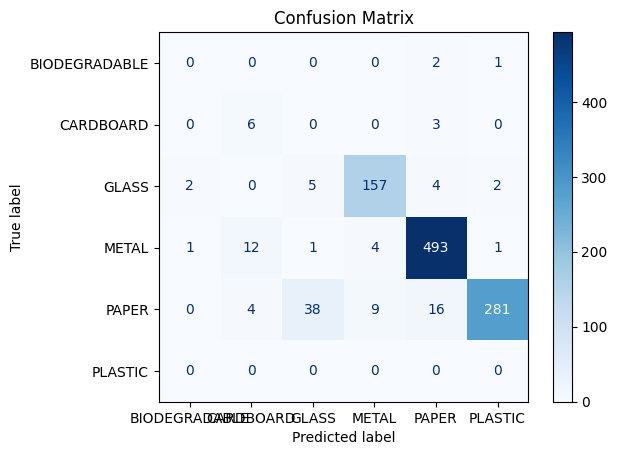

In [ ]:
# ========================
# Transform
# ========================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),                        # 調整大小
    transforms.RandomHorizontalFlip(),                   # 隨機水平翻轉
    transforms.RandomRotation(15),                       # 隨機旋轉
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),  # 色彩抖動
    transforms.ToTensor(),                               # 轉換成 Tensor
    transforms.Normalize([0.5]*3, [0.5]*3),               # 正規化
    transforms.RandomErasing(p=0.2)                       # Tensor 上隨機遮蔽（必須放最後）
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# ========================
# Dataset / Dataloader
# ========================
train_dataset = datasets.ImageFolder(os.path.join(imagefolder_root, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(imagefolder_root, "valid"), transform=test_transform)
test_dataset = datasets.ImageFolder(os.path.join(imagefolder_root, "test"), transform=test_transform)

num_classes = len(train_dataset.classes)
class_names = train_dataset.classes

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# ========================
# Model
# ========================
model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
model.to(device)

# ========================
# Training
# ========================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for images, labels in tqdm(train_loader, desc=f"[Train] Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Train Loss: {total_loss / len(train_loader):.4f}")

    # ========================
    # Validation
    # ========================
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    print(f"Epoch {epoch+1} | Val Loss: {val_loss / len(val_loader):.4f}, Val Acc: {correct / total:.4f}")
    scheduler.step()

# ========================
# Evaluation & Confusion Matrix
# ========================
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


Classification Report:
               precision    recall  f1-score   support

BIODEGRADABLE       0.00      0.00      0.00         3
    CARDBOARD       0.27      0.67      0.39         9
        GLASS       0.11      0.03      0.05       170
        METAL       0.02      0.01      0.01       512
        PAPER       0.03      0.05      0.04       348
      PLASTIC       0.00      0.00      0.00         0

     accuracy                           0.03      1042
    macro avg       0.07      0.12      0.08      1042
 weighted avg       0.04      0.03      0.03      1042



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
!unrar x /content/imagefolder_resplit.rar /content/imagefolder_resplit/

ストリーミング出力は最後の 5000 行に切り捨てられました。
Extracting  /content/imagefolder_resplit/imagefolder_resplit/train/GLASS/glass3087_jpg.rf.467bf1499aa9c7b27acbbb9eed4c5226.jpg      52%  OK 
Extracting  /content/imagefolder_resplit/imagefolder_resplit/train/GLASS/glass3089_jpg.rf.c71e3e1716388e7c5c4d969a51bf060d.jpg      52%  OK 
Extracting  /content/imagefolder_resplit/imagefolder_resplit/train/GLASS/glass308_jpg.rf.af00cb3c529ea6706f925533e87d98ad.jpg      52%  OK 
Extracting  /content/imagefolder_resplit/imagefolder_resplit/train/GLASS/glass3090_jpg.rf.34ef9249a9a11c23d679c8805a70395c.jpg      52%  OK 
Extracting  /content/imagefolder_resplit/imagefolder_resplit/train/GLASS/glass3091_jpg.rf.1c55218cac443f45f4d3f4003edef79f.jpg      52%  OK 
Extracting  /content/imagefolder_resplit/imagefolder_resplit/train/GLASS/glass3093_jpg.rf.00dc24bb93137ecdbc36c1d63e00b27b.jpg      52%  OK 
Extracting  /content/imagefolder_resplit/imagefolder_resplit/train/GL

In [ ]:
from collections import defaultdict
import os

# 定義根目錄（注意這裡要改成 imagefolder_resplit）
imagefolder_root = "/content/imagefolder_resplit/imagefolder_resplit"

def count_images_per_class(root_dir):
    class_counts = defaultdict(int)
    for class_name in os.listdir(root_dir):
        class_dir = os.path.join(root_dir, class_name)
        if os.path.isdir(class_dir):
            count = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            class_counts[class_name] = count
    return class_counts

# 分別統計 train / valid / test 資料夾
for split in ["train", "valid", "test"]:
    print(f"\n=== {split.upper()} set ===")
    path = os.path.join(imagefolder_root, split)
    counts = count_images_per_class(path)
    for class_name, count in sorted(counts.items()):
        print(f"{class_name:<15}: {count} 張")



=== TRAIN set ===
BIODEGRADABLE  : 1554 張
CARDBOARD      : 1018 張
GLASS          : 1852 張
METAL          : 874 張
PAPER          : 1210 張
PLASTIC        : 814 張

=== VALID set ===
BIODEGRADABLE  : 333 張
CARDBOARD      : 218 張
GLASS          : 397 張
METAL          : 187 張
PAPER          : 259 張
PLASTIC        : 175 張

=== TEST set ===
BIODEGRADABLE  : 333 張
CARDBOARD      : 219 張
GLASS          : 398 張
METAL          : 188 張
PAPER          : 260 張
PLASTIC        : 175 張


最基礎 PyTorch + timm ViT 訓練模板

[Train] Epoch 1/10: 100%|██████████| 229/229 [00:39<00:00,  5.73it/s]

Epoch 1 | Train Loss: 0.3290


Epoch 1 | Val Loss: 0.2445, Val Acc: 0.9197


[Train] Epoch 2/10: 100%|██████████| 229/229 [00:32<00:00,  6.98it/s]

Epoch 2 | Train Loss: 0.0837


...

Epoch 9 | Train Loss: 0.0204


Epoch 9 | Val Loss: 0.3199, Val Acc: 0.9191


[Train] Epoch 10/10: 100%|██████████| 229/229 [00:33<00:00,  6.88it/s]

Epoch 10 | Train Loss: 0.0243


Epoch 10 | Val Loss: 0.3644, Val Acc: 0.9191


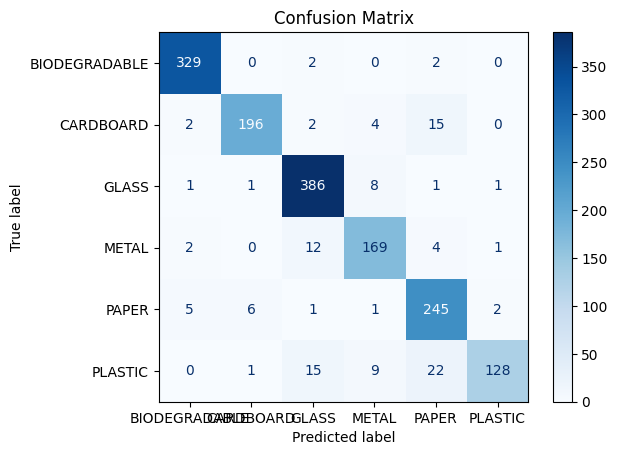

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from tqdm import tqdm

# ===== Config =====
imagefolder_root = "/content/imagefolder_resplit/imagefolder_resplit"
model_name = "vit_tiny_patch16_224"
batch_size = 32
num_epochs = 10
lr = 1e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== Transform (No Augmentation) =====
basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# ===== Dataset / Dataloader =====
train_dataset = datasets.ImageFolder(os.path.join(imagefolder_root, "train"), transform=basic_transform)
val_dataset = datasets.ImageFolder(os.path.join(imagefolder_root, "valid"), transform=basic_transform)
test_dataset = datasets.ImageFolder(os.path.join(imagefolder_root, "test"), transform=basic_transform)

num_classes = len(train_dataset.classes)
class_names = train_dataset.classes

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# ===== Model =====
model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
model.to(device)

# ===== Training =====
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for images, labels in tqdm(train_loader, desc=f"[Train] Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} | Train Loss: {total_loss / len(train_loader):.4f}")

    # Validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    print(f"Epoch {epoch+1} | Val Loss: {val_loss / len(val_loader):.4f}, Val Acc: {correct / total:.4f}")

# ===== Test & Confusion Matrix =====
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()


In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


Classification Report:
               precision    recall  f1-score   support

BIODEGRADABLE       0.97      0.99      0.98       333
    CARDBOARD       0.96      0.89      0.93       219
        GLASS       0.92      0.97      0.95       398
        METAL       0.88      0.90      0.89       188
        PAPER       0.85      0.94      0.89       260
      PLASTIC       0.97      0.73      0.83       175

     accuracy                           0.92      1573
    macro avg       0.93      0.90      0.91      1573
 weighted avg       0.93      0.92      0.92      1573



小進階

[Train] Epoch 1/10: 100%|██████████| 229/229 [00:48<00:00,  4.74it/s]

Epoch 1 | Train Loss: 0.4429


Epoch 1 | Val Loss: 0.2218, Val Acc: 0.9267


[Train] Epoch 2/10: 100%|██████████| 229/229 [00:47<00:00,  4.82it/s]

Epoch 2 | Train Loss: 0.2228


...

Epoch 9 | Train Loss: 0.0388


Epoch 9 | Val Loss: 0.1686, Val Acc: 0.9471


[Train] Epoch 10/10: 100%|██████████| 229/229 [00:48<00:00,  4.76it/s]

Epoch 10 | Train Loss: 0.0396


Epoch 10 | Val Loss: 0.2013, Val Acc: 0.9401


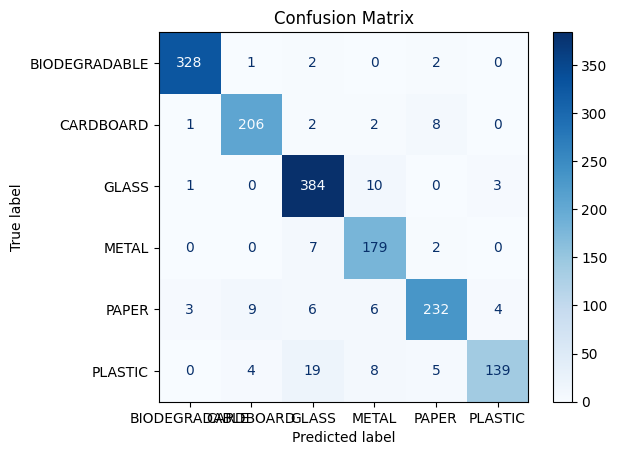

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import timm
from tqdm import tqdm
from torch.optim.lr_scheduler import StepLR
import numpy as np

# ========================
# Config
# ========================
imagefolder_root = "/content/imagefolder_resplit/imagefolder_resplit"
model_name = "vit_tiny_patch16_224"
batch_size = 32
num_epochs = 10
lr = 1e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ========================
# Transform
# ========================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),                        # 調整大小
    transforms.RandomHorizontalFlip(),                   # 隨機水平翻轉
    transforms.RandomRotation(15),                       # 隨機旋轉
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),  # 色彩抖動
    transforms.ToTensor(),                               # 轉換成 Tensor
    transforms.Normalize([0.5]*3, [0.5]*3),               # 正規化
    transforms.RandomErasing(p=0.2)                       # Tensor 上隨機遮蔽（必須放最後）
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# ========================
# Dataset / Dataloader
# ========================
train_dataset = datasets.ImageFolder(os.path.join(imagefolder_root, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(imagefolder_root, "valid"), transform=test_transform)
test_dataset = datasets.ImageFolder(os.path.join(imagefolder_root, "test"), transform=test_transform)

num_classes = len(train_dataset.classes)
class_names = train_dataset.classes

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# ========================
# Model
# ========================
model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
model.to(device)

# ========================
# Training
# ========================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for images, labels in tqdm(train_loader, desc=f"[Train] Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Train Loss: {total_loss / len(train_loader):.4f}")

    # ========================
    # Validation
    # ========================
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    print(f"Epoch {epoch+1} | Val Loss: {val_loss / len(val_loader):.4f}, Val Acc: {correct / total:.4f}")
    scheduler.step()

# ========================
# Evaluation & Confusion Matrix
# ========================
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


Classification Report:
               precision    recall  f1-score   support

BIODEGRADABLE       0.98      0.98      0.98       333
    CARDBOARD       0.94      0.94      0.94       219
        GLASS       0.91      0.96      0.94       398
        METAL       0.87      0.95      0.91       188
        PAPER       0.93      0.89      0.91       260
      PLASTIC       0.95      0.79      0.87       175

     accuracy                           0.93      1573
    macro avg       0.93      0.92      0.93      1573
 weighted avg       0.93      0.93      0.93      1573



[Train] Epoch 1/50: 100%|██████████| 229/229 [00:55<00:00,  4.09it/s]

Epoch 1 | Train Loss: 1.1664


Epoch 1 | Val Loss: 0.4138, Val Acc: 0.8910


[Train] Epoch 2/50: 100%|██████████| 229/229 [00:55<00:00,  4.11it/s]

Epoch 2 | Train Loss: 1.0350


...

Epoch 12 | Train Loss: 0.8735


Epoch 12 | Val Loss: 0.2960, Val Acc: 0.9446
No improvement for 4 epoch(s)


[Train] Epoch 13/50: 100%|██████████| 229/229 [00:55<00:00,  4.16it/s]

Epoch 13 | Train Loss: 0.8565


Epoch 13 | Val Loss: 0.2703, Val Acc: 0.9439
No improvement for 5 epoch(s)
Early stopping triggered at epoch 13


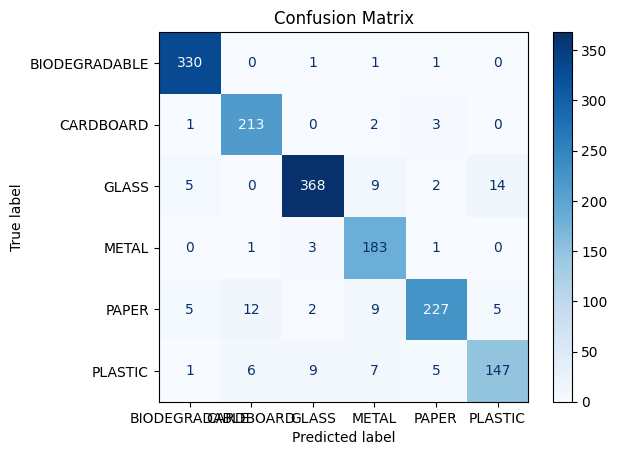

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import timm
from tqdm import tqdm
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
from timm.data import Mixup
from timm.loss import SoftTargetCrossEntropy

# ========================
# Config
# ========================
imagefolder_root = "/content/imagefolder_resplit/imagefolder_resplit"
model_name = "vit_tiny_patch16_224"
batch_size = 32
num_epochs = 50
lr = 1e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ========================
# Transform (Stronger Augmentations)
# ========================
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
    transforms.RandomErasing(p=0.2)
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# ========================
# Dataset / Dataloader
# ========================
train_dataset = datasets.ImageFolder(os.path.join(imagefolder_root, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(imagefolder_root, "valid"), transform=test_transform)
test_dataset = datasets.ImageFolder(os.path.join(imagefolder_root, "test"), transform=test_transform)

num_classes = len(train_dataset.classes)
class_names = train_dataset.classes

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# ========================
# Model with dropout tuning
# ========================
model = timm.create_model(
    model_name,
    pretrained=True,
    num_classes=num_classes,
    drop_rate=0.2,
    attn_drop_rate=0.1
)
model.to(device)

# ========================
# Training Setup
# ========================
criterion_train = SoftTargetCrossEntropy()
criterion_val = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
mixup_fn = Mixup(
    mixup_alpha=0.2,
    cutmix_alpha=1.0,
    label_smoothing=0.1,
    num_classes=num_classes
)

# ========================
# Early Stopping Config
# ========================
early_stop_patience = 5
best_val_loss = float('inf')
epochs_without_improve = 0

# ========================
# Training Loop (with Early Stopping)
# ========================
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for images, labels in tqdm(train_loader, desc=f"[Train] Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)

        # Apply mixup
        if mixup_fn is not None:
            images, labels = mixup_fn(images, labels)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion_train(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Train Loss: {total_loss / len(train_loader):.4f}")

    # Validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion_val(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct / total
    print(f"Epoch {epoch+1} | Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")
    scheduler.step()

    # Early Stopping Check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improve = 0
        # Optional: save best model
        torch.save(model.state_dict(), 'best_vit_model.pth')
    else:
        epochs_without_improve += 1
        print(f"No improvement for {epochs_without_improve} epoch(s)")
        if epochs_without_improve >= early_stop_patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# ========================
# Evaluation & Confusion Matrix
# ========================
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()


In [ ]:
# === Classification report ===
from sklearn.metrics import classification_report
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

Classification Report:
               precision    recall  f1-score   support

BIODEGRADABLE       0.96      0.99      0.98       333
    CARDBOARD       0.92      0.97      0.94       219
        GLASS       0.96      0.92      0.94       398
        METAL       0.87      0.97      0.92       188
        PAPER       0.95      0.87      0.91       260
      PLASTIC       0.89      0.84      0.86       175

     accuracy                           0.93      1573
    macro avg       0.92      0.93      0.93      1573
 weighted avg       0.93      0.93      0.93      1573



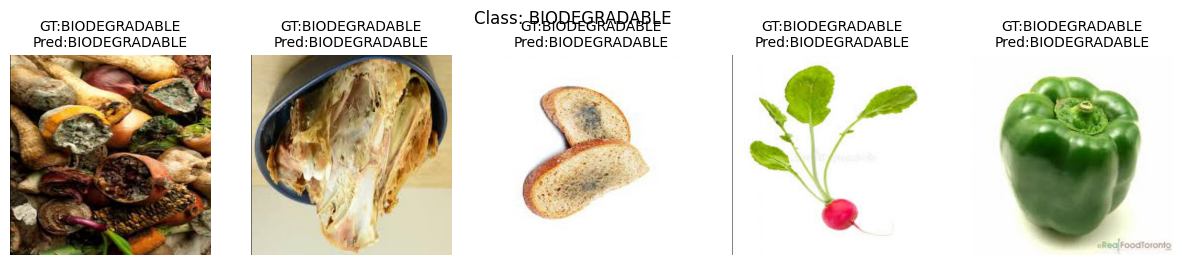

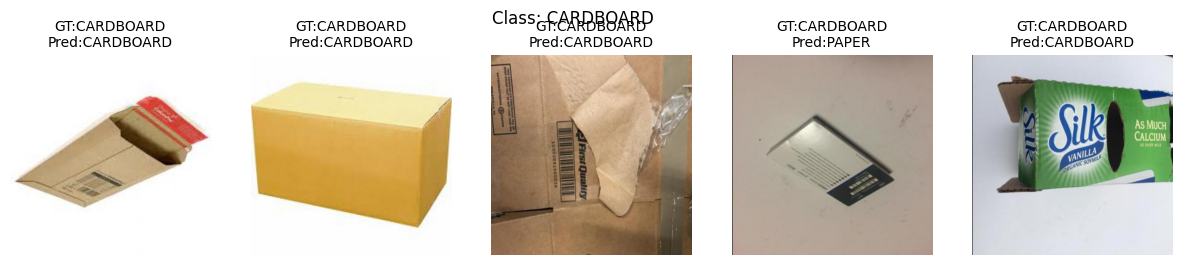

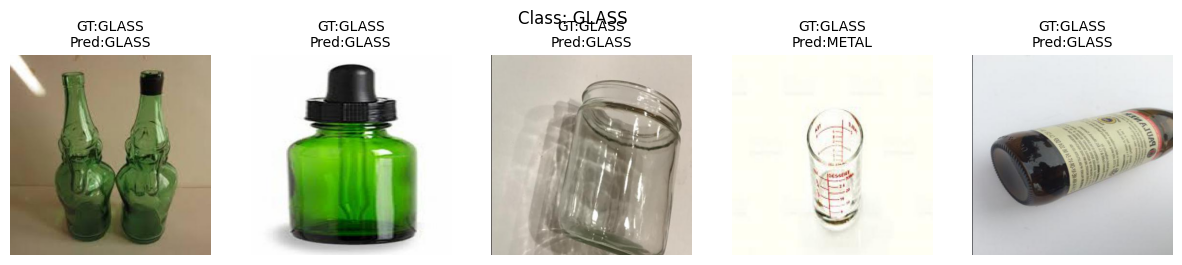

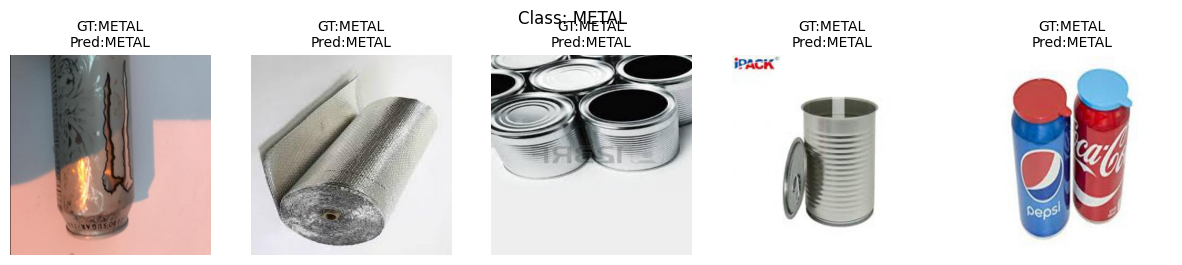

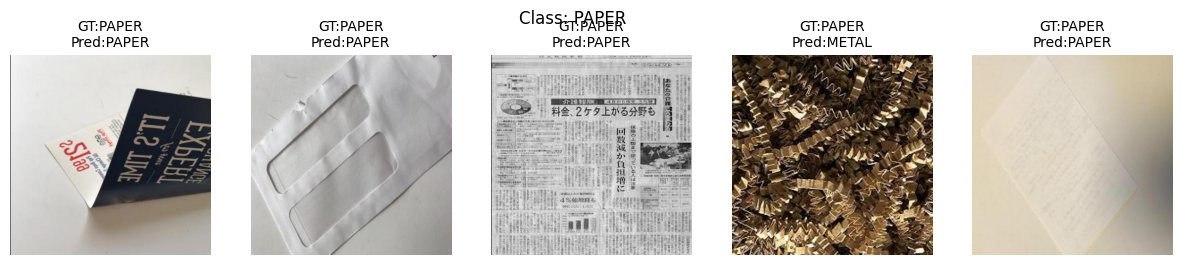

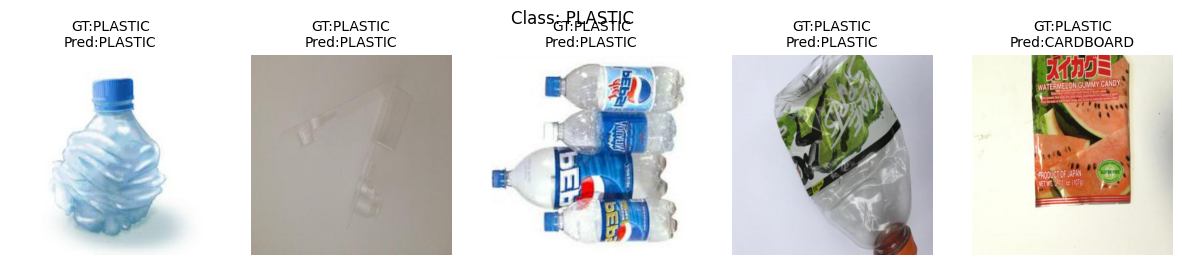

In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
import torch
import timm
from torchvision import transforms

# 1. 設定 test 資料夾路徑與 class 名稱
test_dir = '/content/imagefolder_resplit/imagefolder_resplit/test'
class_names = sorted(os.listdir(test_dir))

# 2. 指定每類要隨機抽取的圖片數
num_samples = 5

# 3. 設定影像預處理（跟你 model 測試用的 test_transform 一樣）
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# 4. 載入模型（確保和你上面訓練時設定一樣，且已經load weights）
model.eval()

# 5. 隨機挑選並顯示每一類5張圖片的實際/預測
for class_idx, class_name in enumerate(class_names):
    img_dir = os.path.join(test_dir, class_name)
    img_files = os.listdir(img_dir)
    img_samples = random.sample(img_files, min(num_samples, len(img_files)))

    plt.figure(figsize=(15, 3))
    plt.suptitle(f"Class: {class_name}")
    for i, img_file in enumerate(img_samples):
        img_path = os.path.join(img_dir, img_file)
        img = Image.open(img_path).convert("RGB")
        img_tensor = test_transform(img).unsqueeze(0).to(device)

        # 預測
        with torch.no_grad():
            output = model(img_tensor)
            pred_idx = output.argmax(dim=1).item()
            pred_class = class_names[pred_idx]

        # 顯示
        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)
        plt.title(f"GT:{class_name}\nPred:{pred_class}", fontsize=10)
        plt.axis('off')
    plt.show()


In [ ]:
from google.colab import files
files.download('best_vit_model.pth')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

未來要使用時，你只需要：

python
コピーする
編集する
model = timm.create_model(
    model_name,
    pretrained=False,      # 記得不要再加預訓練
    num_classes=num_classes,
    drop_rate=0.2,
    attn_drop_rate=0.1
)
model.load_state_dict(torch.load('best_vit_model.pth', map_location='cpu'))  # 路徑請用你自己的
model.eval()

In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.7 MB/s eta 0:00:00


In [ ]:
!unrar x /content/yolo_resplit.rar /content/yolo_resplit/

ストリーミング出力は最後の 5000 行に切り捨てられました。
Extracting  /content/yolo_resplit/yolo_resplit/train/labels/paper1252_jpg.rf.e1c477fe703651d9957c9a83a2a968e2.txt      84%  OK 
Extracting  /content/yolo_resplit/yolo_resplit/train/labels/paper1254_jpg.rf.f064daf9f418f983320c633f486e2261.txt      84%  OK 
Extracting  /content/yolo_resplit/yolo_resplit/train/labels/paper1255_jpg.rf.aa5bcab3d9b91ebc85aec9aa0096fb44.txt      84%  OK 
Extracting  /content/yolo_resplit/yolo_resplit/train/labels/paper1256_jpg.rf.a8154f48c939f118acc1c172749611a6.txt      84%  OK 
Extracting  /content/yolo_resplit/yolo_resplit/train/labels/paper1257_jpg.rf.f26ea1ffc2241221dc6fbbc86a05734c.txt      84%  OK 
Extracting  /content/yolo_resplit/yolo_resplit/train/labels/paper1258_jpg.rf.b08865b024da3dcdaf1467a155522fdf.txt      84%  OK 
Extracting  /content/yolo_resplit/yolo_resplit/train/labels/paper125_jpg.rf.edefe33d318fca6be02e3816a153f035.txt      84%  OK 
Extracting

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')

model.train(
    data='/content/yolo_resplit/yolo_resplit/data.yaml',
    epochs=30,
    imgsz=320,
    batch=-1,
    workers=4,
    name='yolo_resplit_run',
    project='/content/runs/train',
    pretrained=True,
    optimizer='AdamW',
    lr0=0.001,
    freeze=0,
    amp=True,
    verbose=True,
    patience=5,  # Early stopping

    # Data Augmentation
    mosaic=1.0,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    flipud=0.5,
    erasing=0.4
)


Ultralytics 8.3.167 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_resplit/yolo_resplit/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_resplit_run3, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=5, perspective=0.0, plots=Tr

100%|██████████| 755k/755k [00:00<00:00, 18.4MB/s]

Overriding model.yaml nc=80 with nc=6

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics

Model summary: 129 layers, 11,137,922 parameters, 11,137,906 gradients, 28.7 GFLOPs

Transferred 349/355 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...


100%|██████████| 5.35M/5.35M [00:00<00:00, 89.5MB/s]
/usr/local/lib/python3.11/dist-packages/ultralytics/utils/torch_utils.py:272: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:217.)
  fusedconv.weight.copy_(torch.mm(w_bn, w_conv).view(fusedconv.weight.shape))
/usr/local/lib/python3.11/dist-packages/ultralytics/utils/torch_utils.py:281: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::C

...

/usr/local/lib/python3.11/dist-packages/ultralytics/utils/torch_utils.py:272: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:217.)
  fusedconv.weight.copy_(torch.mm(w_bn, w_conv).view(fusedconv.weight.shape))
/usr/local/lib/python3.11/dist-packages/ultralytics/utils/torch_utils.py:281: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this o

Model summary (fused): 72 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [00:12<00:00,  1.22s/it]


                   all       1573      11571      0.736      0.574      0.651      0.464
         BIODEGRADABLE        348       7169      0.747      0.518      0.612      0.341
             CARDBOARD        231        736      0.634      0.467      0.534      0.409
                 GLASS        406       1234      0.799       0.66      0.739      0.547
                 METAL        290        856      0.731      0.675      0.726       0.54
                 PAPER        266        735      0.755       0.51      0.612      0.489
               PLASTIC        223        841      0.748      0.614      0.684      0.459
Speed: 0.1ms preprocess, 1.3ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /content/runs/train/yolo_resplit_run3


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e46a0b8d210>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [ ]:
from ultralytics import YOLO

# Load the best trained model
model = YOLO('/content/runs/train/yolo_resplit_run3/weights/best.pt')

# Perform evaluation on the test set with Test-Time Augmentation (TTA) enabled
metrics = model.val(
    data='/content/yolo_resplit/yolo_resplit/data.yaml',
    split='test',
    augment=True,
    project='runs/detect',
    name='resplit_test_eval'
)

# Print key evaluation metrics
print("mAP50:", metrics.box.map50)         # Mean Average Precision at IoU threshold 0.5
print("mAP50-95:", metrics.box.map)        # Mean Average Precision averaged over IoU thresholds from 0.5 to 0.95
print("Precision (mean):", metrics.box.mp) # Mean precision across all classes
print("Recall (mean):", metrics.box.mr)    # Mean recall across all classes
print("Per-class AP@50:", metrics.box.ap50)   # AP@0.5 for each class
print("Per-class AP@50-95:", metrics.box.ap)  # AP@0.5–0.95 for each class


Ultralytics 8.3.167 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 518.5±374.6 MB/s, size: 18.7 KB)


val: Scanning /content/yolo_resplit/yolo_resplit/test/labels... 1573 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1573/1573 [00:01<00:00, 1406.06it/s]


val: New cache created: /content/yolo_resplit/yolo_resplit/test/labels.cache


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 99/99 [00:21<00:00,  4.58it/s]


                   all       1573      11584      0.746      0.593      0.675      0.496
         BIODEGRADABLE        339       7017      0.748      0.516      0.619      0.358
             CARDBOARD        224        782      0.701      0.505      0.599      0.453
                 GLASS        401       1369      0.789      0.628      0.682      0.535
                 METAL        286        897      0.758      0.697      0.746      0.565
                 PAPER        265        677      0.773      0.575      0.694      0.547
               PLASTIC        227        842      0.708      0.638       0.71      0.519
Speed: 0.2ms preprocess, 7.3ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to runs/detect/resplit_test_eval
mAP50: 0.6751336104935048
mAP50-95: 0.4962662632412986
Precision (mean): 0.7462115116062932
Recall (mean): 0.5930227038226418
Per-class AP@50: [    0.61946     0.59947      0.6816     0.74621     0.69415     0.70992]
Per-class AP@50-95: [    0.3582

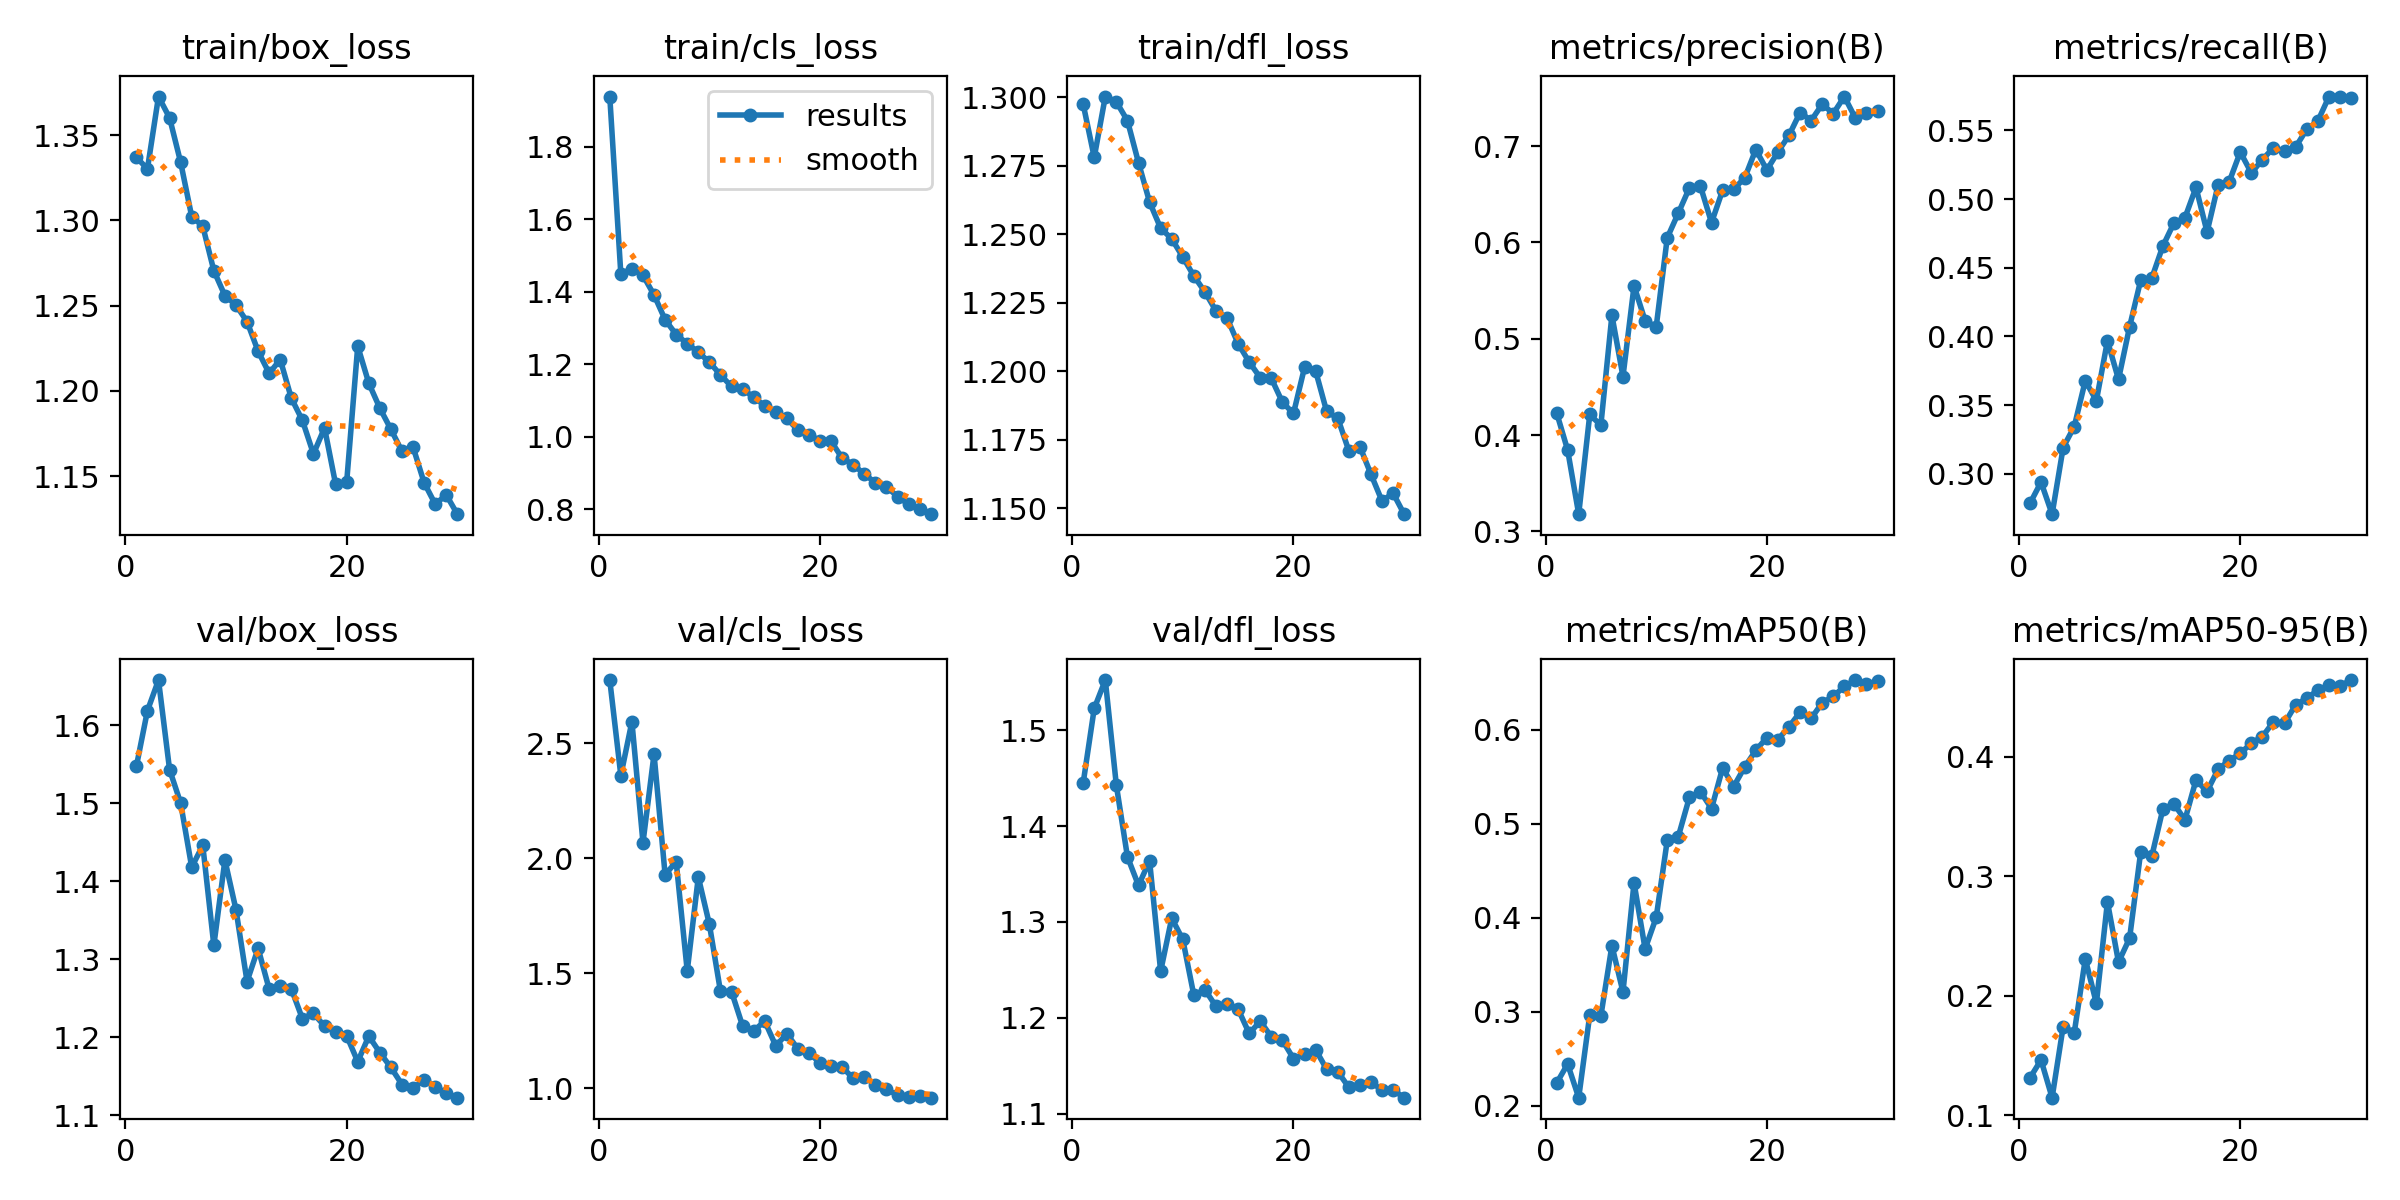

In [ ]:
import pandas as pd
from IPython.display import Image

# Load training metrics
df = pd.read_csv('/content/runs/train/yolo_resplit_run3/results.csv')
df.tail()

# Plot training curves (loss, mAP)
Image(filename='/content/runs/train/yolo_resplit_run3/results.png')

In [ ]:
from ultralytics import YOLO


model = YOLO('/content/runs/train/yolo_resplit_run3/weights/best.pt')


model.train(
    data='/content/yolo_resplit/yolo_resplit/data.yaml',
    epochs=60,
    imgsz=320,
    batch=-1,
    workers=4,
    name='yolo_resplit_run4',
    project='/content/runs/train',
    pretrained=False,
    optimizer='AdamW',
    lr0=0.0005,
    freeze=0,
    amp=True,
    patience=5,

    # Data Augmentation
    mosaic=1.0,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    flipud=0.5,
    erasing=0.4
)


Ultralytics 8.3.167 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_resplit/yolo_resplit/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/train/yolo_resplit_run3/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_resplit_run4, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask

/usr/local/lib/python3.11/dist-packages/ultralytics/utils/torch_utils.py:272: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:217.)
  fusedconv.weight.copy_(torch.mm(w_bn, w_conv).view(fusedconv.weight.shape))
/usr/local/lib/python3.11/dist-packages/ultralytics/utils/torch_utils.py:281: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this o

AMP: checks passed ✅


/usr/local/lib/python3.11/dist-packages/ultralytics/nn/modules/block.py:1357: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:217.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/usr/local/lib/python3.11/dist-packages/ultralytics/nn/modules/block.py:1359: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic 

train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 672.2±315.5 MB/s, size: 17.2 KB)


...

                   all       1573      11571      0.741      0.536      0.619      0.431
EarlyStopping: Training stopped early as no improvement observed in last 5 epochs. Best results observed at epoch 11, best model saved as best.pt.
To update EarlyStopping(patience=5) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



16 epochs completed in 0.250 hours.
Optimizer stripped from /content/runs/train/yolo_resplit_run4/weights/last.pt, 22.5MB
Optimizer stripped from /content/runs/train/yolo_resplit_run4/weights/best.pt, 22.5MB

Validating /content/runs/train/yolo_resplit_run4/weights/best.pt...
Ultralytics 8.3.167 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs


/usr/local/lib/python3.11/dist-packages/ultralytics/utils/torch_utils.py:272: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:217.)
  fusedconv.weight.copy_(torch.mm(w_bn, w_conv).view(fusedconv.weight.shape))
/usr/local/lib/python3.11/dist-packages/ultralytics/utils/torch_utils.py:281: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this o

                   all       1573      11571      0.712      0.543      0.619      0.436
         BIODEGRADABLE        348       7169      0.734      0.496       0.58       0.32
             CARDBOARD        231        736       0.68       0.41      0.504      0.379
                 GLASS        406       1234      0.726      0.638      0.693      0.518
                 METAL        290        856       0.73      0.629      0.693      0.501
                 PAPER        266        735      0.695       0.49      0.569       0.45
               PLASTIC        223        841      0.707      0.596      0.675      0.448
Speed: 0.1ms preprocess, 1.3ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/runs/train/yolo_resplit_run4


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e4630804ed0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     